# Notebook 09 — Sensitivity Analysis
Compute station-level weather sensitivity/resilience scores,
rank stations, and produce policy-ready outputs.

## 0. Imports & Load

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats as stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel      = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
site_stats = pd.read_parquet(PROCESSED / "site_classification.parquet")

panel_good = panel[panel["low_coverage"] == False].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"panel_good  : {panel_good.shape}")
print(f"site_stats  : {site_stats.shape}")
print(f"date range  : {panel_good['date'].min().date()} → {panel_good['date'].max().date()}")

panel_good  : (145768, 54)
site_stats  : (133, 14)
date range  : 2023-01-01 → 2025-12-31


## 1. Station-Level Resilience Scores
**Method:** for each station, `resilience = bad_weather_avg / good_weather_avg`  
Score ≈ 1.0 → weather has little effect (resilient)  
Score ≪ 1.0 → demand collapses in bad weather (sensitive)

In [2]:
def compute_resilience(df, weather_col, label):
    good = df[df[weather_col] == False].groupby("site ID")["aantal"].mean()
    bad  = df[df[weather_col] == True].groupby("site ID")["aantal"].mean()
    return (bad / good).rename(label)

r_rain = compute_resilience(panel_good, "is_rainy_day",  "resilience_rain") 
r_cold = compute_resilience(panel_good, "is_cold_day",   "resilience_cold") 
r_wind = compute_resilience(panel_good, "is_windy_day",  "resilience_wind") 
r_any  = compute_resilience(panel_good, "is_bad_weather", "resilience_any") 

resilience = (
    pd.DataFrame({"site ID": panel_good["site ID"].unique()})
    .set_index("site ID")
    .join([r_rain, r_cold, r_wind, r_any])
    .reset_index()
)

resilience["resilience_score"] = (
    resilience["resilience_rain"] * 0.45 +
    resilience["resilience_cold"] * 0.25 +
    resilience["resilience_wind"] * 0.20 +
    resilience["resilience_any"]  * 0.10
)

resilience = resilience.merge(
    site_stats[["site ID", "naam", "gemeente", "avg_daily",
                "site_type", "lon", "lat"]],
    on="site ID", how="left"
)

resilience["sensitivity_rank"] = resilience["resilience_score"].rank(
    ascending=True
).astype(int)
resilience = resilience.sort_values("sensitivity_rank")

print("Resilience score distribution:")
print(resilience["resilience_score"].describe().round(3))
print()
print("Top 15 most sensitive stations (lowest resilience):")
print(resilience.head(15)[["naam", "gemeente", "site_type",
                            "resilience_score", "avg_daily"]].to_string(index=False))
print()
print("Top 15 most resilient stations (highest resilience):")
print(resilience.nlargest(15, "resilience_score")[
    ["naam", "gemeente", "site_type", "resilience_score", "avg_daily"]
].to_string(index=False))
print()
lt_rank = resilience.loc[resilience["site ID"] == 107, "sensitivity_rank"].values
lt_score = resilience.loc[resilience["site ID"] == 107, "resilience_score"].values
print(f"Leuven Totem (site ID 107): sensitivity rank #{lt_rank[0]}, "
      f"resilience score {lt_score[0]:.3f}")

Resilience score distribution:
count    133.000
mean       0.631
std        0.096
min        0.330
25%        0.586
50%        0.631
75%        0.689
max        0.846
Name: resilience_score, dtype: float64

Top 15 most sensitive stations (lowest resilience):
                      naam             gemeente site_type  resilience_score   avg_daily
                        As                   As   leisure          0.329600  598.664856
      Houthalen-Helchteren Houthalen-Helchteren   leisure          0.391295  449.631836
          Nieuwpoort totem           Nieuwpoort   leisure          0.397025 1043.638794
       Nieuwpoort teller 1           Nieuwpoort   leisure          0.401325 2117.738770
            Heers teller 1                Heers   leisure          0.412358   64.965797
                     Heers                Heers   leisure          0.413620   61.350204
          Maaseik teller 2              Maaseik     mixed          0.444064  444.544464
          Maaseik teller 1           

## 2. Sensitivity by Site Type

In [3]:
by_type = resilience.groupby("site_type")[
    ["resilience_rain", "resilience_cold",
     "resilience_wind", "resilience_score"]
].mean().round(3)
print("Average resilience by site type:")
print(by_type)

Average resilience by site type:
           resilience_rain  resilience_cold  resilience_wind  resilience_score
site_type                                                                     
commuter             0.731            0.715            0.457             0.666
leisure              0.667            0.591            0.373             0.581
mixed                0.693            0.651            0.410             0.619


/var/folders/99/f5nk7g8n09g1gdgwc7k9scjc0000gn/T/ipykernel_77479/1043470222.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_melted, x="Weather_Condition", y="Resilience_Score",


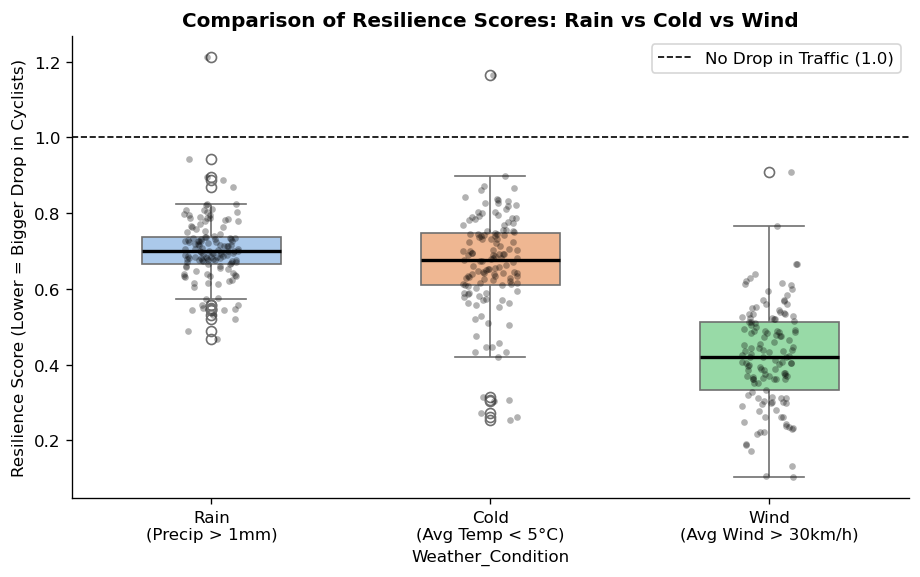

In [4]:
# ── 1. check the sensitivity by bad weather types────────────────────────────────
weather_vars = ["resilience_rain", "resilience_cold", "resilience_wind"]
data_melted = resilience.melt(id_vars=["site ID", "naam"], 
                              value_vars=weather_vars,
                              var_name="Weather_Condition", 
                              value_name="Resilience_Score")

plt.figure(figsize=(9, 5), dpi=120)

sns.boxplot(data=data_melted, x="Weather_Condition", y="Resilience_Score", 
            palette="pastel", width=0.5, medianprops=dict(color="black", linewidth=2))
sns.stripplot(data=data_melted, x="Weather_Condition", y="Resilience_Score", 
              color="black", alpha=0.3, jitter=True, size=4)

plt.axhline(1.0, color="black", linestyle="--", linewidth=1, label="No Drop in Traffic (1.0)")
plt.title("Comparison of Resilience Scores: Rain vs Cold vs Wind", fontweight="bold")
plt.ylabel("Resilience Score (Lower = Bigger Drop in Cyclists)")
plt.xticks(ticks=[0, 1, 2], labels=["Rain\n(Precip > 1mm)", "Cold\n(Avg Temp < 5°C)", "Wind\n(Avg Wind > 30km/h)"])
plt.legend()
sns.despine()
plt.show()

In [5]:
# ── 2. Friedman Test for Overall Significance ─────────────────────────
# The Friedman Test is a non-parametric statistical test used to detect differences in treatments across multiple test attempts. 
# It is often used when the data is in the form of rankings or ordinal data, and when you have more than two related groups or repeated measures. 
# The Friedman test is the non-parametric alternative to the repeated measures ANOVA and is useful when the assumptions of normality and homogeneity of variances are not met
# source: https://www.geeksforgeeks.org/dsa/friedman-test/

print("="*70)
print("1. OVERALL SIGNIFICANCE (Friedman Test)")
print("   (H0: Rain, Cold, and Wind have the same impact on cycling traffic)")
print("="*70)

# same stations under three conditions → repeated measures → Friedman Test
rain_scores = resilience["resilience_rain"].values
cold_scores = resilience["resilience_cold"].values
wind_scores = resilience["resilience_wind"].values

stat_friedman, p_friedman = stats.friedmanchisquare(rain_scores, cold_scores, wind_scores)
print(f"Friedman Test p-value : {p_friedman:.5e}")

# ── 3. Wilcoxon Signed-Rank Test ───────────
if p_friedman < 0.05:
    print("\n" + "="*70)
    print("2. PAIRWISE COMPARISON (Wilcoxon Signed-Rank Test with Bonferroni)")
    print("="*70)
    
    pairs = [
        ("Rain vs Cold", rain_scores, cold_scores),
        ("Rain vs Wind", rain_scores, wind_scores),
        ("Cold vs Wind", cold_scores, wind_scores)
    ]
    
    print(f"{'Comparison':<15} | {'Mean Diff':<12} | {'Adj. p-value':<15} | {'Significance'}")
    print("-" * 70)
    for name, s1, s2 in pairs:
        # calculate the mean difference, to see which has lower scores (more impactful)
        mean_diff = s1.mean() - s2.mean() 
        
        # Wilcoxon paired test: one sided test to see if s1 is significantly lower than s2 (more impactful)
        _, p_wilcoxon = stats.wilcoxon(s1, s2, alternative='less')
        
        # Bonferroni 
        p_adj = min(p_wilcoxon * 3, 1.0)
        sig = "***" if p_adj < 0.01 else ("*" if p_adj < 0.05 else "ns")
        
        print(f"{name:<15} | {mean_diff:>12.3f} | {p_adj:<15.4f} | {sig}")
        
    print("\n (Interpretation):")
    print(f"Rain mean score: {rain_scores.mean():.3f} (Lower means worse traffic drop)")
    print(f"Cold mean score: {cold_scores.mean():.3f}")
    print(f"Wind mean score: {wind_scores.mean():.3f}")

1. OVERALL SIGNIFICANCE (Friedman Test)
   (H0: Rain, Cold, and Wind have the same impact on cycling traffic)
Friedman Test p-value : 7.65645e-44

2. PAIRWISE COMPARISON (Wilcoxon Signed-Rank Test with Bonferroni)
Comparison      | Mean Diff    | Adj. p-value    | Significance
----------------------------------------------------------------------
Rain vs Cold    |        0.040 | 1.0000          | ns
Rain vs Wind    |        0.282 | 1.0000          | ns
Cold vs Wind    |        0.242 | 1.0000          | ns

 (Interpretation):
Rain mean score: 0.704 (Lower means worse traffic drop)
Cold mean score: 0.664
Wind mean score: 0.422


In [6]:
# add double sided test results for reference
print("\n\n=== DOUBLE-SIDED TEST RESULTS (for reference) ===")
print("\n" + "="*70)
pairs = [
        ("Rain vs Cold", rain_scores, cold_scores),
        ("Rain vs Wind", rain_scores, wind_scores),
        ("Cold vs Wind", cold_scores, wind_scores)
    ]
    
print(f"{'Comparison':<15} | {'Mean Diff':<12} | {'Adj. p-value':<15} | {'Significance'}")
print("-" * 70)
for name, s1, s2 in pairs:
    # calculate the mean difference, to see which has lower scores (more impactful)
    mean_diff = s1.mean() - s2.mean() 
        
     # Wilcoxon paired test
    _, p_wilcoxon = stats.wilcoxon(s1, s2, alternative='two-sided')
        
     # Bonferroni 
    p_adj = min(p_wilcoxon * 3, 1.0)
    sig = "***" if p_adj < 0.01 else ("*" if p_adj < 0.05 else "ns")
        
    print(f"{name:<15} | {mean_diff:>12.3f} | {p_adj:<15.4f} | {sig}")
        
    print("\n (Interpretation):")
    print(f"Rain mean score: {rain_scores.mean():.3f} (Lower means worse traffic drop)")
    print(f"Cold mean score: {cold_scores.mean():.3f}")
    print(f"Wind mean score: {wind_scores.mean():.3f}")



=== DOUBLE-SIDED TEST RESULTS (for reference) ===

Comparison      | Mean Diff    | Adj. p-value    | Significance
----------------------------------------------------------------------
Rain vs Cold    |        0.040 | 0.0000          | ***

 (Interpretation):
Rain mean score: 0.704 (Lower means worse traffic drop)
Cold mean score: 0.664
Wind mean score: 0.422
Rain vs Wind    |        0.282 | 0.0000          | ***

 (Interpretation):
Rain mean score: 0.704 (Lower means worse traffic drop)
Cold mean score: 0.664
Wind mean score: 0.422
Cold vs Wind    |        0.242 | 0.0000          | ***

 (Interpretation):
Rain mean score: 0.704 (Lower means worse traffic drop)
Cold mean score: 0.664
Wind mean score: 0.422


## 3. Commuting-Period Weather Sensitivity

In [7]:
def commute_effects(df):
    morning = df[df["precip_morning"] > 0.5]["aantal"].mean() / \
              df[df["precip_morning"] <= 0.5]["aantal"].mean() - 1
    evening = df[df["precip_evening"] > 0.5]["aantal"].mean() / \
              df[df["precip_evening"] <= 0.5]["aantal"].mean() - 1
    return pd.Series({"morning_rain_effect": morning,
                      "evening_rain_effect": evening})

commute_sensitivity = (
    panel_good.groupby("site ID")
    .apply(commute_effects, include_groups=False)
    .reset_index()
    .merge(site_stats[["site ID", "naam", "site_type"]], on="site ID")
)

ct = commute_sensitivity.groupby("site_type")[
    ["morning_rain_effect", "evening_rain_effect"]
].mean().round(3)
print("Commute-period rain effect by site type:")
print(ct)

c_morn = ct.loc["commuter", "morning_rain_effect"]
l_morn = ct.loc["leisure",  "morning_rain_effect"]
rel    = (c_morn - l_morn) / abs(l_morn) * 100
print(f"\nCommuters are {abs(rel):.1f}% less affected than leisure "
      f"by morning rain")

Commute-period rain effect by site type:
           morning_rain_effect  evening_rain_effect
site_type                                          
commuter                -0.358               -0.255
leisure                 -0.432               -0.331
mixed                   -0.409               -0.298

Commuters are 17.1% less affected than leisure by morning rain


## 4. Priority Infrastructure List

In [8]:
resilience["priority_score"] = (
    (1 - resilience["resilience_score"]) *
    np.log1p(resilience["avg_daily"])
)
resilience["priority_rank"] = resilience["priority_score"].rank(
    ascending=False
).astype(int)

priority_list = resilience.sort_values("priority_rank").head(20)[
    ["priority_rank", "naam", "gemeente", "site_type",
     "avg_daily", "resilience_score", "resilience_rain",
     "resilience_cold", "resilience_wind", "priority_score"]
]
print("Top 20 Priority Stations for Infrastructure Investment:")
print(priority_list.to_string(index=False))

Top 20 Priority Stations for Infrastructure Investment:
 priority_rank                 naam             gemeente site_type   avg_daily  resilience_score  resilience_rain  resilience_cold  resilience_wind  priority_score
             1  Nieuwpoort teller 1           Nieuwpoort   leisure 2117.738770          0.401325         0.544893         0.271693         0.228666        4.585001
             2                   As                   As   leisure  598.664856          0.329600         0.467122         0.254500         0.103098        4.288129
             3     Nieuwpoort totem           Nieuwpoort   leisure 1043.638794          0.397025         0.544032         0.262462         0.221914        4.191538
             4 Houthalen-Helchteren Houthalen-Helchteren   leisure  449.631836          0.391295         0.549689         0.315039         0.105062        3.719581
             5     Maaseik teller 2              Maaseik     mixed  444.544464          0.444064         0.558699         0.

## 5. Visualisations

### Resilience Score Distribution

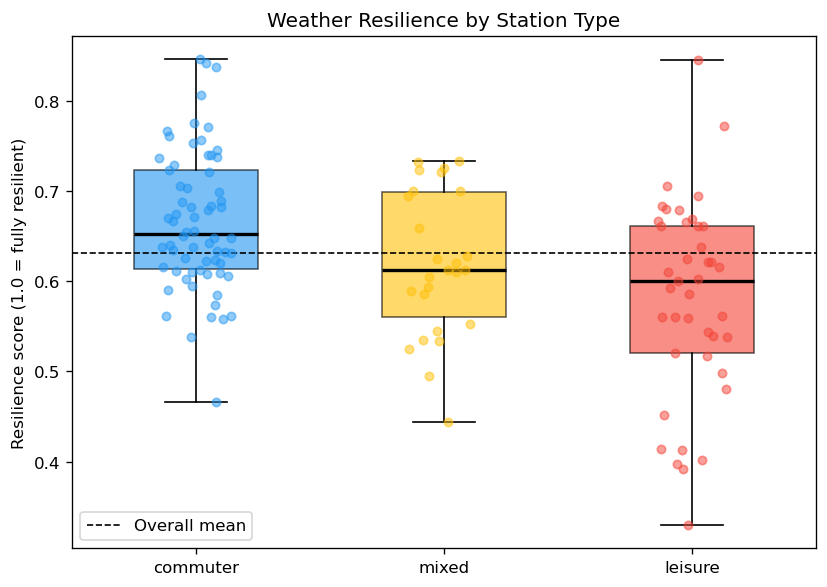

09_resilience_distribution.png saved.


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

order       = ["commuter", "mixed", "leisure"]
data        = [resilience[resilience["site_type"] == st]["resilience_score"].values
               for st in order]
colors_list = [COLORS[st] for st in order]

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

rng = np.random.default_rng(42)
for i, (d, color) in enumerate(zip(data, colors_list), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(i + jitter, d, color=color, alpha=0.5, s=25, zorder=3)

ax.axhline(resilience["resilience_score"].mean(),
           color="black", linestyle="--", linewidth=1, label="Overall mean")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(order)
ax.set_ylabel("Resilience score (1.0 = fully resilient)")
ax.set_title("Weather Resilience by Station Type")
ax.legend()

fig.tight_layout()
fig.savefig(FIGS / "09_resilience_distribution.png", dpi=150)
plt.show()
print("09_resilience_distribution.png saved.")

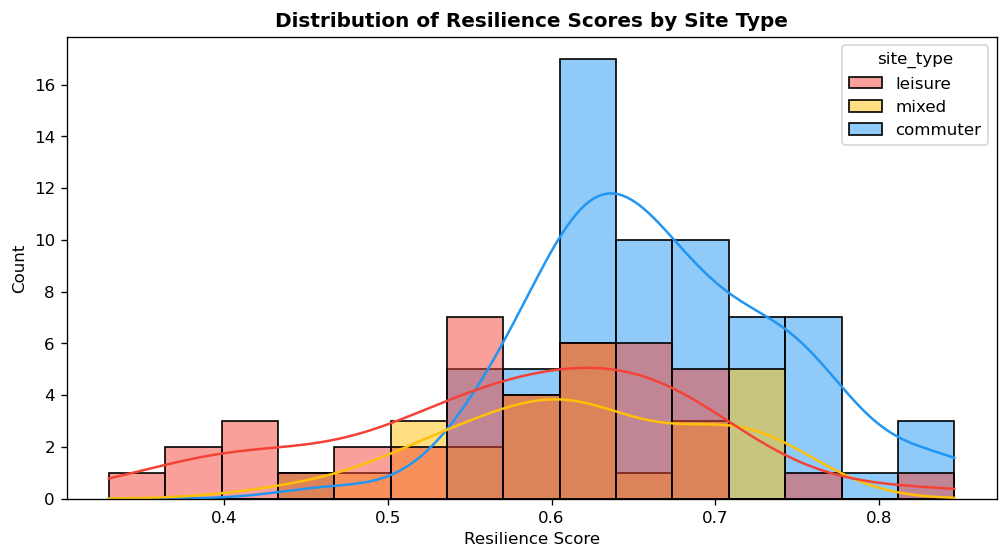

In [10]:
plt.figure(figsize=(10, 5), dpi=120)
sns.histplot(data=resilience, x="resilience_score", hue="site_type", 
             kde=True, palette=COLORS, alpha=0.5, bins=15)
plt.title("Distribution of Resilience Scores by Site Type", fontweight="bold")
plt.xlabel("Resilience Score")
plt.ylabel("Count")
plt.show()

In [11]:
# check normality and variance homogeneity for ANOVA assumptions
print("="*60)
print("1. NORMALITY TEST (Shapiro-Wilk)")
print("   (H0: The data is normally distributed; p > 0.05 is good)")
print("="*60)
stat, p_norm = stats.shapiro(resilience["resilience_score"])
print(f"Overall Score Normal: p-value = {p_norm:.4f} \n (Note: This tests the entire dataset, but we also need to check each site type separately)")

groups = [resilience[resilience["site_type"] == st]["resilience_score"].values for st in ["commuter", "leisure", "mixed"]]
for st, grp in zip(["commuter", "leisure", "mixed"], groups):
    _, p = stats.shapiro(grp)
    print(f"  - {st:<10}: p-value = {p:.4f}")

print("\n" + "="*60)
print("2. VARIANCE HOMOGENEITY TEST (Levene's Test)")
print("   (H0: All groups have equal variances; p > 0.05 is good)")
print("="*60)
stat, p_levene = stats.levene(*groups)
print(f"Equal Variance: p-value = {p_levene:.4f}")

1. NORMALITY TEST (Shapiro-Wilk)
   (H0: The data is normally distributed; p > 0.05 is good)
Overall Score Normal: p-value = 0.0410 
 (Note: This tests the entire dataset, but we also need to check each site type separately)
  - commuter  : p-value = 0.3530
  - leisure   : p-value = 0.3426
  - mixed     : p-value = 0.2039

2. VARIANCE HOMOGENEITY TEST (Levene's Test)
   (H0: All groups have equal variances; p > 0.05 is good)
Equal Variance: p-value = 0.0689


In [12]:
# we have non-nomality and heteroscedasticity, so we go with non-parametric Kruskal-Wallis test
stat_kw, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis test p-value : {p_kw:.5f}")

if p_kw < 0.05:
    print("\nResult: SIGNIFICANT DIFFERENCE DETECTED! Performing pairwise checks (Mann-Whitney U):")
    pairs = [("commuter", "leisure"), ("commuter", "mixed"), ("leisure", "mixed")]
    for st1, st2 in pairs:
        g1 = resilience[resilience["site_type"] == st1]["resilience_score"]
        g2 = resilience[resilience["site_type"] == st2]["resilience_score"]
        _, p_pair = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        
        #  Bonferroni correction for multiple comparisons (3 pairs)
        p_adj = min(p_pair * 3, 1.0) 
        sig = "***" if p_adj < 0.01 else ("*" if p_adj < 0.05 else "not significant")
        print(f"  {st1:<10} vs {st2:<10} | adjusted p-val = {p_adj:.4f} {sig}")

Kruskal-Wallis test p-value : 0.00015

Result: SIGNIFICANT DIFFERENCE DETECTED! Performing pairwise checks (Mann-Whitney U):
  commuter   vs leisure    | adjusted p-val = 0.0002 ***
  commuter   vs mixed      | adjusted p-val = 0.0450 *
  leisure    vs mixed      | adjusted p-val = 0.5363 not significant


### Priority Map

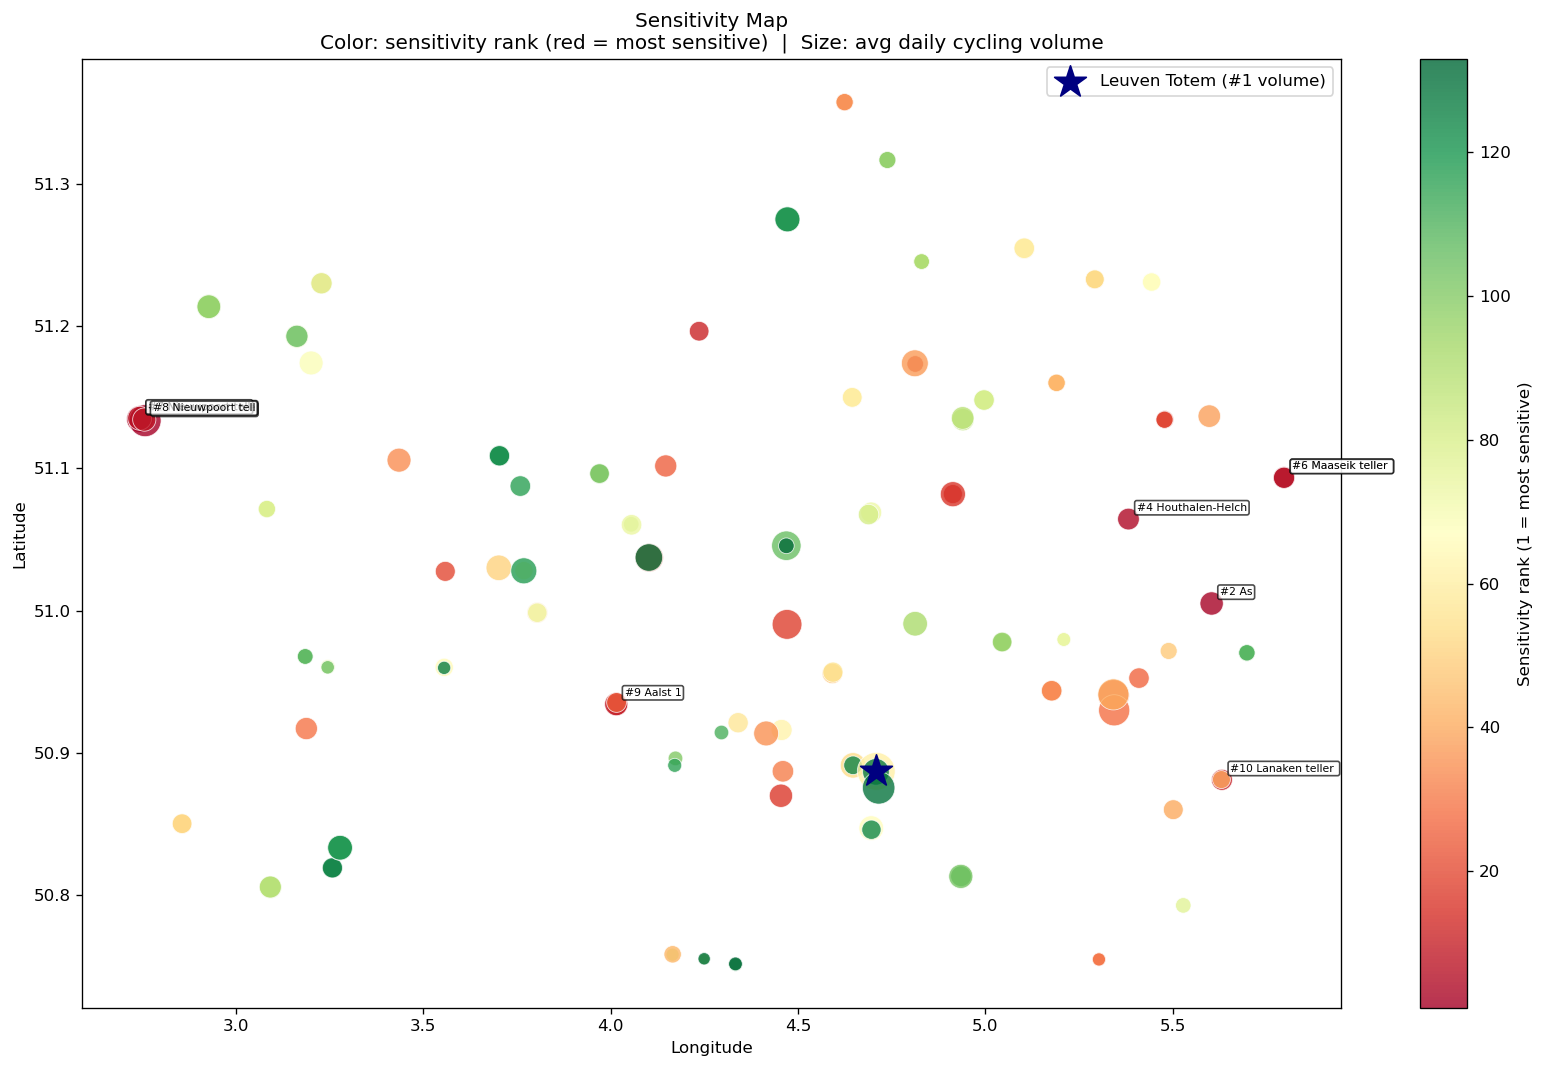

09_sensitivity_map saved.


In [13]:
fig, ax = plt.subplots(figsize=(14, 9))

cmap       = plt.cm.RdYlGn
norm_color = mcolors.Normalize(
    vmin=resilience["priority_rank"].min(),
    vmax=resilience["priority_rank"].max(),
)

scatter = ax.scatter(
    resilience["lon"],
    resilience["lat"],
    c=resilience["priority_rank"],
    cmap=cmap,
    norm=norm_color,
    s=np.sqrt(resilience["avg_daily"]) * 8,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)

top10 = resilience.sort_values("priority_rank").head(10)
for _, row in top10.iterrows():
    ax.annotate(
        f"#{int(row['priority_rank'])} {row['naam'][:15]}",
        (row["lon"], row["lat"]),
        fontsize=6.5,
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
    )

lt = resilience[resilience["site ID"] == 107]
ax.scatter(lt["lon"], lt["lat"], color="navy", marker="*",
           s=400, zorder=10, label="Leuven Totem (#1 volume)")

plt.colorbar(scatter, ax=ax, label="Sensitivity rank (1 = most sensitive)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Sensitivity Map\n"
    "Color: sensitivity rank (red = most sensitive)  |  Size: avg daily cycling volume",
    fontsize=12,
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "09_sensitivity_map.png", dpi=150)
plt.show()
print("09_sensitivity_map saved.")

### Top 15 Sensitive vs Top 15 Resilient

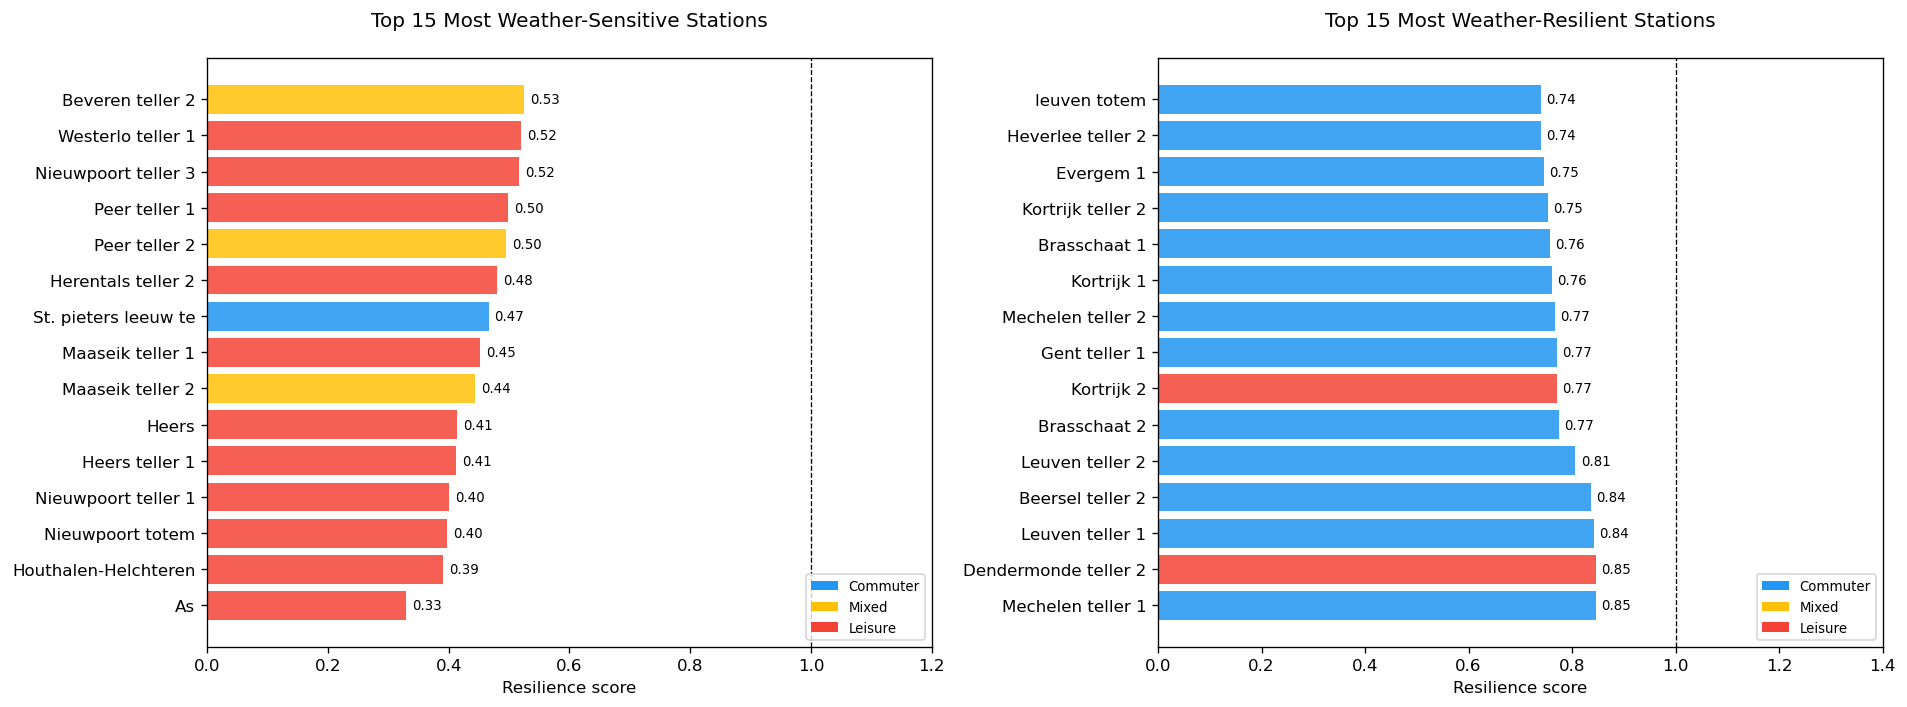

09_sensitive_vs_resilient saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

legend_elements = [
    Patch(facecolor=COLORS["commuter"], label="Commuter"),
    Patch(facecolor=COLORS["mixed"],    label="Mixed"),
    Patch(facecolor=COLORS["leisure"],  label="Leisure"),
]

# Left: top 15 most sensitive
ax = axes[0]
sensitive_15 = resilience.head(15).sort_values("resilience_score", ascending=True)
colors_s = [COLORS.get(st, "gray") for st in sensitive_15["site_type"]]
bars = ax.barh(sensitive_15["naam"].str[:20],
               sensitive_15["resilience_score"],
               color=colors_s, alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Resilience score")
ax.set_title("Top 15 Most Weather-Sensitive Stations\n")
ax.set_xlim(0, 1.2)
for bar, val in zip(bars, sensitive_15["resilience_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

# Right: top 15 most resilient
ax = axes[1]
resilient_15 = resilience.nlargest(15, "resilience_score").sort_values(
    "resilience_score", ascending=False)
colors_r = [COLORS.get(st, "gray") for st in resilient_15["site_type"]]
bars = ax.barh(resilient_15["naam"].str[:20],
               resilient_15["resilience_score"],
               color=colors_r, alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Resilience score")
ax.set_title("Top 15 Most Weather-Resilient Stations\n")
ax.set_xlim(0, 1.4)
for bar, val in zip(bars, resilient_15["resilience_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

fig.tight_layout()
fig.savefig(FIGS / "09_sensitive_vs_resilient.png", dpi=150)
plt.show()
print("09_sensitive_vs_resilient saved.")

## 6. Save Resilience Results

In [15]:
resilience.to_parquet(PROCESSED / "station_resilience.parquet", index=False)
print(f"Saved: {PROCESSED / 'station_resilience.parquet'}")

Saved: /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/station_resilience.parquet


## 7. Final Summary

In [16]:
n_stations = resilience["site ID"].nunique()
r_mean     = resilience["resilience_score"].mean()
r_median   = resilience["resilience_score"].median()
r_min      = resilience["resilience_score"].min()
r_max      = resilience["resilience_score"].max()
most_sens  = resilience.loc[resilience["resilience_score"].idxmin(), "naam"]
most_resil = resilience.loc[resilience["resilience_score"].idxmax(), "naam"]

by_type_s  = resilience.groupby("site_type")["resilience_score"].mean()

c_morn_pct = ct.loc["commuter", "morning_rain_effect"] * 100
l_morn_pct = ct.loc["leisure",  "morning_rain_effect"] * 100
rel_diff   = (c_morn_pct - l_morn_pct) / abs(l_morn_pct) * 100

top5 = resilience.sort_values("priority_rank").head(5)

lt_row   = resilience[resilience["site ID"] == 107].iloc[0]

print("=" * 52)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 52)
print(f"Stations analysed: {n_stations} (well-covered)")
print()
print("Overall resilience score distribution:")
print(f"  Mean   : {r_mean:.3f}")
print(f"  Median : {r_median:.3f}")
print(f"  Min    : {r_min:.3f}  (most sensitive: {most_sens})")
print(f"  Max    : {r_max:.3f}  (most resilient: {most_resil})")
print()
print("Resilience by site type:")
for st in ["commuter", "mixed", "leisure"]:
    tag = " (most resilient)" if st == "commuter" else \
          " (most sensitive)" if st == "leisure" else ""
    print(f"  {st:10s}: {by_type_s[st]:.3f}{tag}")
print()
print("Commute-period rain effect:")
print(f"  commuter morning rain : {c_morn_pct:+.1f}%")
print(f"  leisure  morning rain : {l_morn_pct:+.1f}%")
print(f"  \u2192 commuters {abs(rel_diff):.1f}% less affected during morning commute")
print()
print("Top 5 Priority Stations for Investment:")
for _, row in top5.iterrows():
    print(f"  #{int(row['priority_rank'])}  {row['naam'][:25]:<25} "
          f"({row['gemeente']}) — "
          f"resilience: {row['resilience_score']:.3f}, "
          f"avg: {row['avg_daily']:.0f}/day")
print()
print("Leuven Totem (site ID 107):")
print(f"  Resilience score : {lt_row['resilience_score']:.3f}")
print(f"  Sensitivity rank : #{int(lt_row['sensitivity_rank'])} / {n_stations}")
print(f"  Priority rank    : #{int(lt_row['priority_rank'])} / {n_stations}")
print(f"  Rain resilience  : {lt_row['resilience_rain']:.3f}")
print(f"  Cold resilience  : {lt_row['resilience_cold']:.3f}")


SENSITIVITY ANALYSIS SUMMARY
Stations analysed: 133 (well-covered)

Overall resilience score distribution:
  Mean   : 0.631
  Median : 0.631
  Min    : 0.330  (most sensitive: As)
  Max    : 0.846  (most resilient: Mechelen teller 1)

Resilience by site type:
  commuter  : 0.666 (most resilient)
  mixed     : 0.619
  leisure   : 0.581 (most sensitive)

Commute-period rain effect:
  commuter morning rain : -35.8%
  leisure  morning rain : -43.2%
  → commuters 17.1% less affected during morning commute

Top 5 Priority Stations for Investment:
  #1  Nieuwpoort teller 1       (Nieuwpoort) — resilience: 0.401, avg: 2118/day
  #2  As                        (As) — resilience: 0.330, avg: 599/day
  #3  Nieuwpoort totem          (Nieuwpoort) — resilience: 0.397, avg: 1044/day
  #4  Houthalen-Helchteren      (Houthalen-Helchteren) — resilience: 0.391, avg: 450/day
  #5  Maaseik teller 2          (Maaseik) — resilience: 0.444, avg: 445/day

Leuven Totem (site ID 107):
  Resilience score : 0.740
 

In [17]:
import folium
import branca.colormap as cm
import numpy as np

# ── 1. calculate center coordinates ─────────────────────────
center_lat = resilience["lat"].mean()
center_lon = resilience["lon"].mean()

# ── 2. open map ───────────────────────
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=13,                   
    tiles="CartoDB positron"         
)
# ── 3. sensitivity spectrum ──────────────
max_rank = resilience["priority_rank"].max()
colormap = cm.LinearColormap(
    colors=["#d73027", "#fee08b", "#1a9850"], 
    vmin=1, 
    vmax=max_rank
)
colormap.caption = "Resilience Rank (1 = Most Vulnerable, Red)"
m.add_child(colormap)

# ── 4. project the sites to the map ─────────────────────────
for _, row in resilience.iterrows():
    radius_size = np.sqrt(row["avg_daily"]) / 5
    
    popup_html = f"""
    <div style="width: 200px;">
        <b>{row['naam']}</b><br>
        <i>{row['gemeente']}</i><hr style="margin:2px;">
        <b>type:</b> {row['site_type']}<br>
        <b>daily average flow:</b> {row['avg_daily']:.0f} vehicles<br>
        <b>resilience score:</b> {row['resilience_score']:.2f}<br>
        <b style="color:red;">resilience rank: #{int(row['priority_rank'])}</b>
    </div>
    """
    
    # add dot with color by priority rank, size by avg_daily, tooltip and popup
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius_size,
        color="white",            
        weight=0.8,               
        fill=True,
        fill_color=colormap(row["priority_rank"]), # color by  rank
        fill_opacity=0.8,
        tooltip=f"#{int(row['priority_rank'])} {row['naam']}", # mouse hover
        popup=folium.Popup(popup_html, max_width=250)          # click popup
    ).add_to(m)

# ── 5. Leuven Totem ───────────────────────
lt = resilience[resilience["site ID"] == 107].iloc[0]
folium.Marker(
    location=[lt["lat"], lt["lon"]],
    tooltip=" Leuven Totem (Top Volume Station) ",
    icon=folium.Icon(color="darkblue", icon="star")
).add_to(m)

m

/var/folders/99/f5nk7g8n09g1gdgwc7k9scjc0000gn/T/ipykernel_77479/2893945482.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Time_of_Week", y="Resilience",


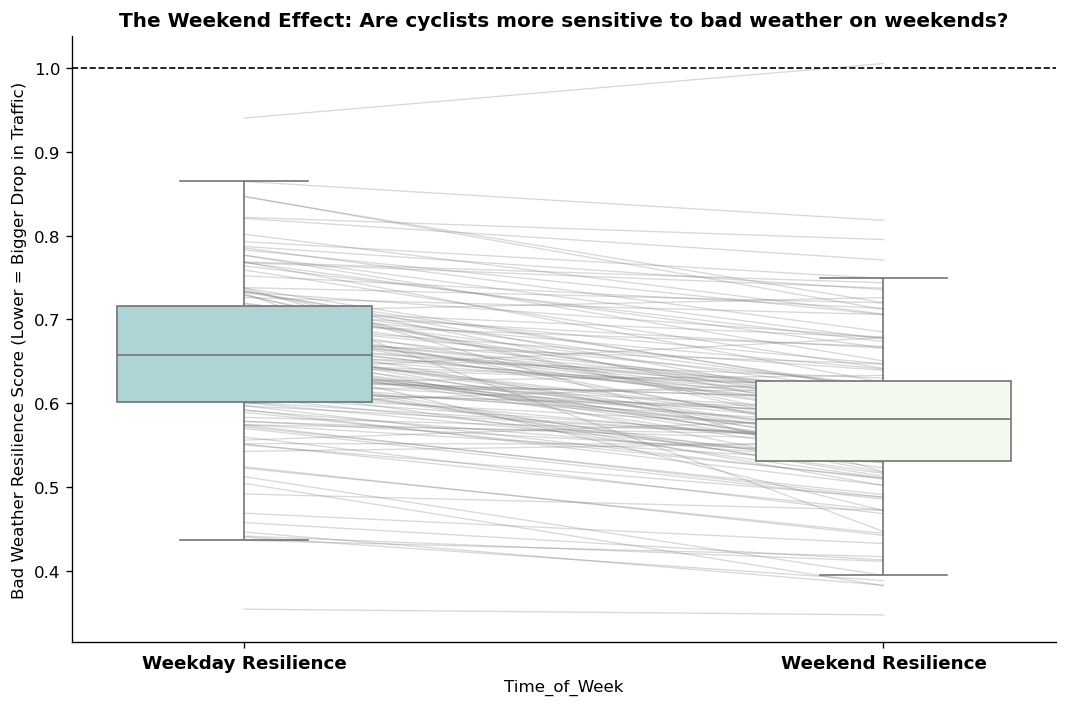

WEEKEND EFFECT HYPOTHESIS TESTING (One-Sided Wilcoxon Test)
  H1 Hypothesis: Resilience on Weekends is LESS than on Weekdays
Average Weekday Bad weather Resilience : 0.656
Average Weekend Bad weather Resilience : 0.583
Mean Difference (Weekend - WD)  : -0.073
One-sided Wilcoxon p-value      : 2.0356e-22  ***

WEEKEND EFFECT BREAKDOWN BY SITE TYPE
           resilience_weekday  resilience_weekend  Diff (Weekend Drop)
site_type                                                             
commuter                0.694               0.608               -0.086
leisure                 0.605               0.541               -0.064
mixed                   0.639               0.585               -0.054

  (Interpretation):
p-value is 2.0356e-22, which is statistically significant at the 0.05 level.
This suggests that cyclists are indeed more sensitive to weather on weekends compared to weekdays.
The boxplot and paired lines also visually support this conclusion, showing a general downward shif

In [18]:
# ── 1. Calculate Weekend/Weekday Resilience ─────────────────────────

def compute_weekend_resilience(df, weather_col="is_bad_weather"):
    # weekday data and calculate resilience
    wd = df[~df["is_weekend"]]
    wd_good = wd[wd[weather_col] == False].groupby("site ID")["aantal"].mean()
    wd_bad  = wd[wd[weather_col] == True].groupby("site ID")["aantal"].mean()
    res_wd = (wd_bad / wd_good).rename("resilience_weekday")
    
    # weekend data and calculate resilience
    we = df[df["is_weekend"]]
    we_good = we[we[weather_col] == False].groupby("site ID")["aantal"].mean()
    we_bad  = we[we[weather_col] == True].groupby("site ID")["aantal"].mean()
    res_we = (we_bad / we_good).rename("resilience_weekend")
    
    # merge
    return pd.concat([res_wd, res_we], axis=1).dropna()

# label 
weekend_res = compute_weekend_resilience(panel_good, weather_col="is_bad_weather")
weekend_res = weekend_res.join(site_stats.set_index("site ID")[["site_type", "naam"]])

# ── 2. Paired Slope Plot and Box Plot ──────────────────
plot_df = weekend_res.melt(id_vars=["site_type", "naam"], 
                           value_vars=["resilience_weekday", "resilience_weekend"],
                           var_name="Time_of_Week", value_name="Resilience")

plt.figure(figsize=(9, 6), dpi=120)
# general performance
sns.boxplot(data=plot_df, x="Time_of_Week", y="Resilience", 
            palette=["#A8DADC", "#F1FAEE"], width=0.4, showfliers=False)

# show the change
for idx, row in weekend_res.iterrows():
    plt.plot([0, 1], [row["resilience_weekday"], row["resilience_weekend"]], 
             color='gray', alpha=0.3, linewidth=0.8, zorder=1)

plt.axhline(1.0, color="black", linestyle="--", linewidth=1, label="No Drop (1.0)")
plt.xticks([0, 1], ["Weekday Resilience", "Weekend Resilience"], fontsize=11, fontweight="bold")
plt.ylabel("Bad Weather Resilience Score (Lower = Bigger Drop in Traffic)")
plt.title("The Weekend Effect: Are cyclists more sensitive to bad weather on weekends?", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

# ── 3. One-Sided Wilcoxon Signed-Rank ──────
print("="*75)
print("WEEKEND EFFECT HYPOTHESIS TESTING (One-Sided Wilcoxon Test)")
print("  H1 Hypothesis: Resilience on Weekends is LESS than on Weekdays")
print("="*75)

s_wd = weekend_res["resilience_weekday"].values
s_we = weekend_res["resilience_weekend"].values

# alternative='less' means we are testing if s_we is significantly less than s_wd (i.e. worse resilience on weekends)
stat, p_val = stats.wilcoxon(s_we, s_wd, alternative='less')
sig = "***" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns")

print(f"Average Weekday Bad weather Resilience : {s_wd.mean():.3f}")
print(f"Average Weekend Bad weather Resilience : {s_we.mean():.3f}")
print(f"Mean Difference (Weekend - WD)  : {s_we.mean() - s_wd.mean():+.3f}")
print(f"One-sided Wilcoxon p-value      : {p_val:.4e}  {sig}")

# ── 4. What site types are most affected? ─────────────────────────
print("\n" + "="*75)
print("WEEKEND EFFECT BREAKDOWN BY SITE TYPE")
print("="*75)
groupby_type = weekend_res.groupby("site_type")[["resilience_weekday", "resilience_weekend"]].mean()
groupby_type["Diff (Weekend Drop)"] = groupby_type["resilience_weekend"] - groupby_type["resilience_weekday"]
print(groupby_type.round(3))

print("\n  (Interpretation):")
if p_val < 0.05:
    print(f"p-value is {p_val:.4e}, which is statistically significant at the 0.05 level.")
    print("This suggests that cyclists are indeed more sensitive to weather on weekends compared to weekdays.")
    print("The boxplot and paired lines also visually support this conclusion, showing a general downward shift in resilience scores from weekdays to weekends.")